<a href="https://colab.research.google.com/github/isabellaschen/Formula-One/blob/main/Final_Project_F1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predictive Model - Formula One

By: Isabella Chen

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import json
import os

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import make_column_transformer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report


In [3]:
# function to pull from different endpoints
base_url = 'https://api.openf1.org/v1/'

def get_data(endpoint, params = None):
  if params is None:
        params = {}

  url = f'{base_url}{endpoint}'
  response = requests.get(url, params = params)

  return pd.DataFrame(response.json())

EDA

In [4]:
# session results endpoint
results = get_data('session_result')

results = results[['session_key',
                   'driver_number',
                   'position']]
results = results.dropna(subset = ['position'])

In [5]:
# weather endpoint - aggregating averages for each session
weather = get_data('weather')

weather_features = (
    weather.groupby('session_key')
    .agg(
        avg_air_temp = ('air_temperature', 'mean'),
        avg_track_temp = ('track_temperature', 'mean'),
        avg_humidity = ('humidity', 'mean'),
        avg_wind_speed = ('wind_speed', 'mean'),
        rain_pct=  ('rainfall', 'mean'),
        is_wet = ('rainfall', 'max')
    )
    .reset_index()
)

# merge onto results dataset
results = results.merge(
    weather_features,
    on='session_key',
    how='left'
)

In [6]:
# driver data endpoint
drivers = get_data('drivers')

drivers = drivers[['session_key',
                   'driver_number',
                   'team_name',
                   'full_name']]

# merge onto results dataset
results = results.merge(
    drivers,
    on=['session_key', 'driver_number'],
    how='left'
)

In [7]:
# stints endpoing
stints = get_data('stints')

# create dummy variable for each tire compound
stints['hard_compound'] = (stints['compound'] == 'HARD').astype(int)
stints['medium_compound'] = (stints['compound'] == 'MEDIUM').astype(int)
stints['soft_compound'] = (stints['compound'] == 'SOFT').astype(int)
stints['intermediate_compound'] = (stints['compound'] == 'INTERMEDIATE').astype(int)
stints['wet_compound'] = (stints['compound'] == 'WET').astype(int)

# aggregate by number of tire compound used by session and driver
stint_features = (
    stints.groupby(['session_key', 'driver_number'])
    .agg(
        hard_compound = ('hard_compound', 'sum'),
        medium_compound = ('medium_compound', 'sum'),
        soft_compound = ('soft_compound', 'sum'),
        intermediate_compound = ('intermediate_compound', 'sum'),
        wet_compound = ('wet_compound', 'sum'),
        total_stints = ('stint_number', 'max')
    )
    .reset_index()
)

# merge onto results dataset
results = results.merge(
    stint_features,
    on=['session_key', 'driver_number'],
    how='left'
)

In [8]:
# create target variable - top 10
results['top_10'] = (results['position'] <= 10).astype(int)


In [9]:
# general spread of top 10 finishes vs non-top 10 finishes
  # this makes sense, 22 drivers start the race.

print(results['top_10'].value_counts(normalize = True))

top_10
1    0.517032
0    0.482968
Name: proportion, dtype: float64


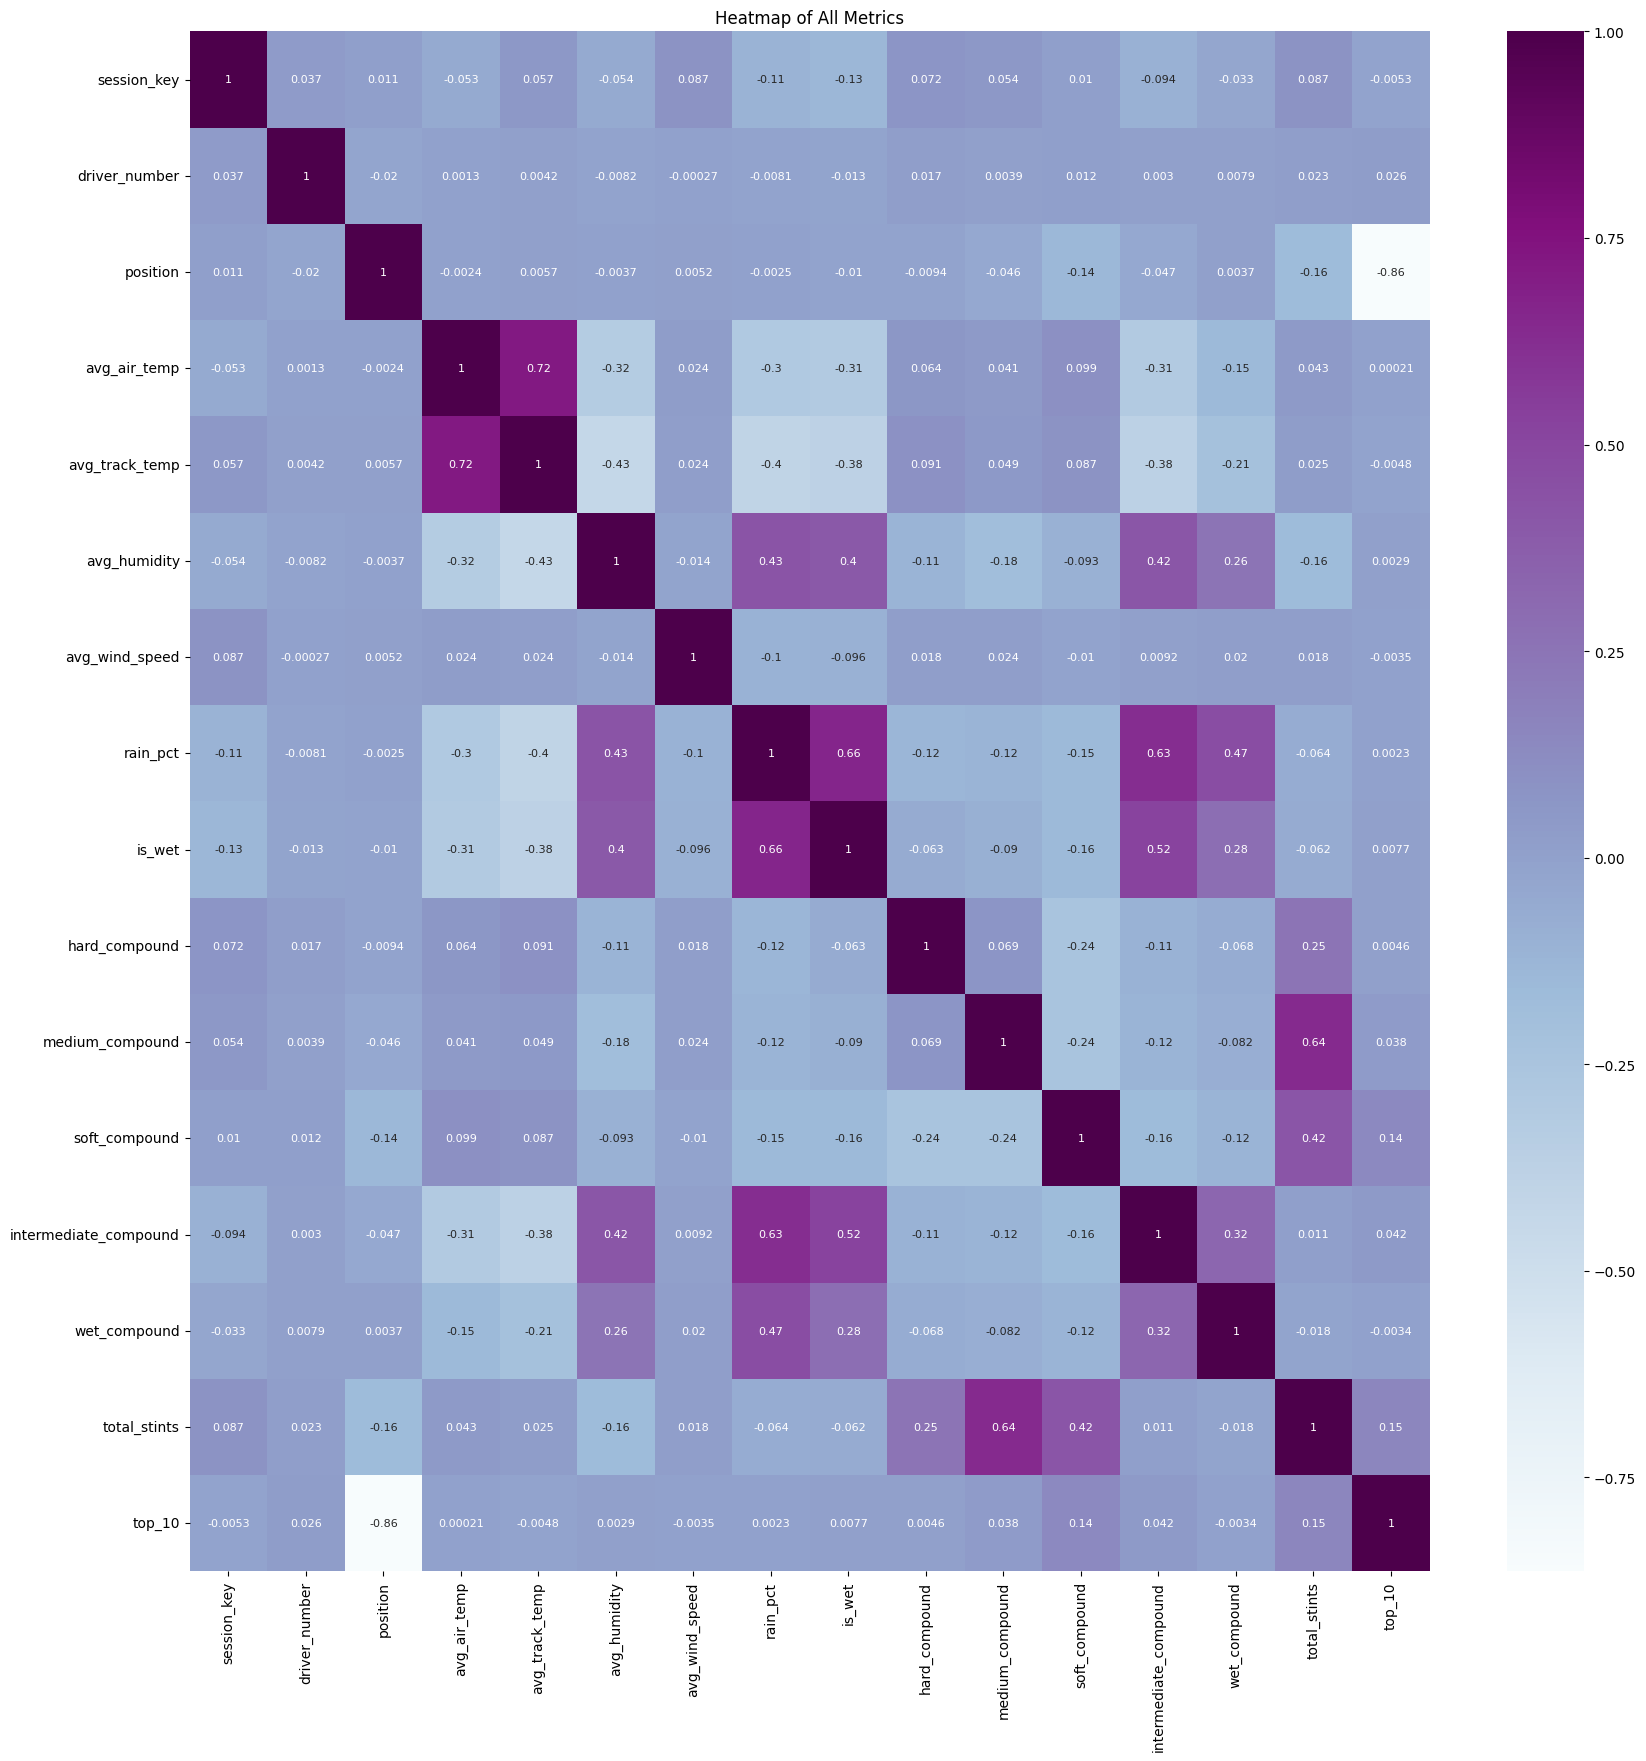

In [10]:
# heatmap of correlations
results_corr = results.corr(numeric_only = True)

plt.figure(figsize=(20, 20))
sns.heatmap(results_corr, annot = True, annot_kws={"size": 8}, cmap = 'BuPu')
plt.title('Heatmap of All Metrics')
plt.show()

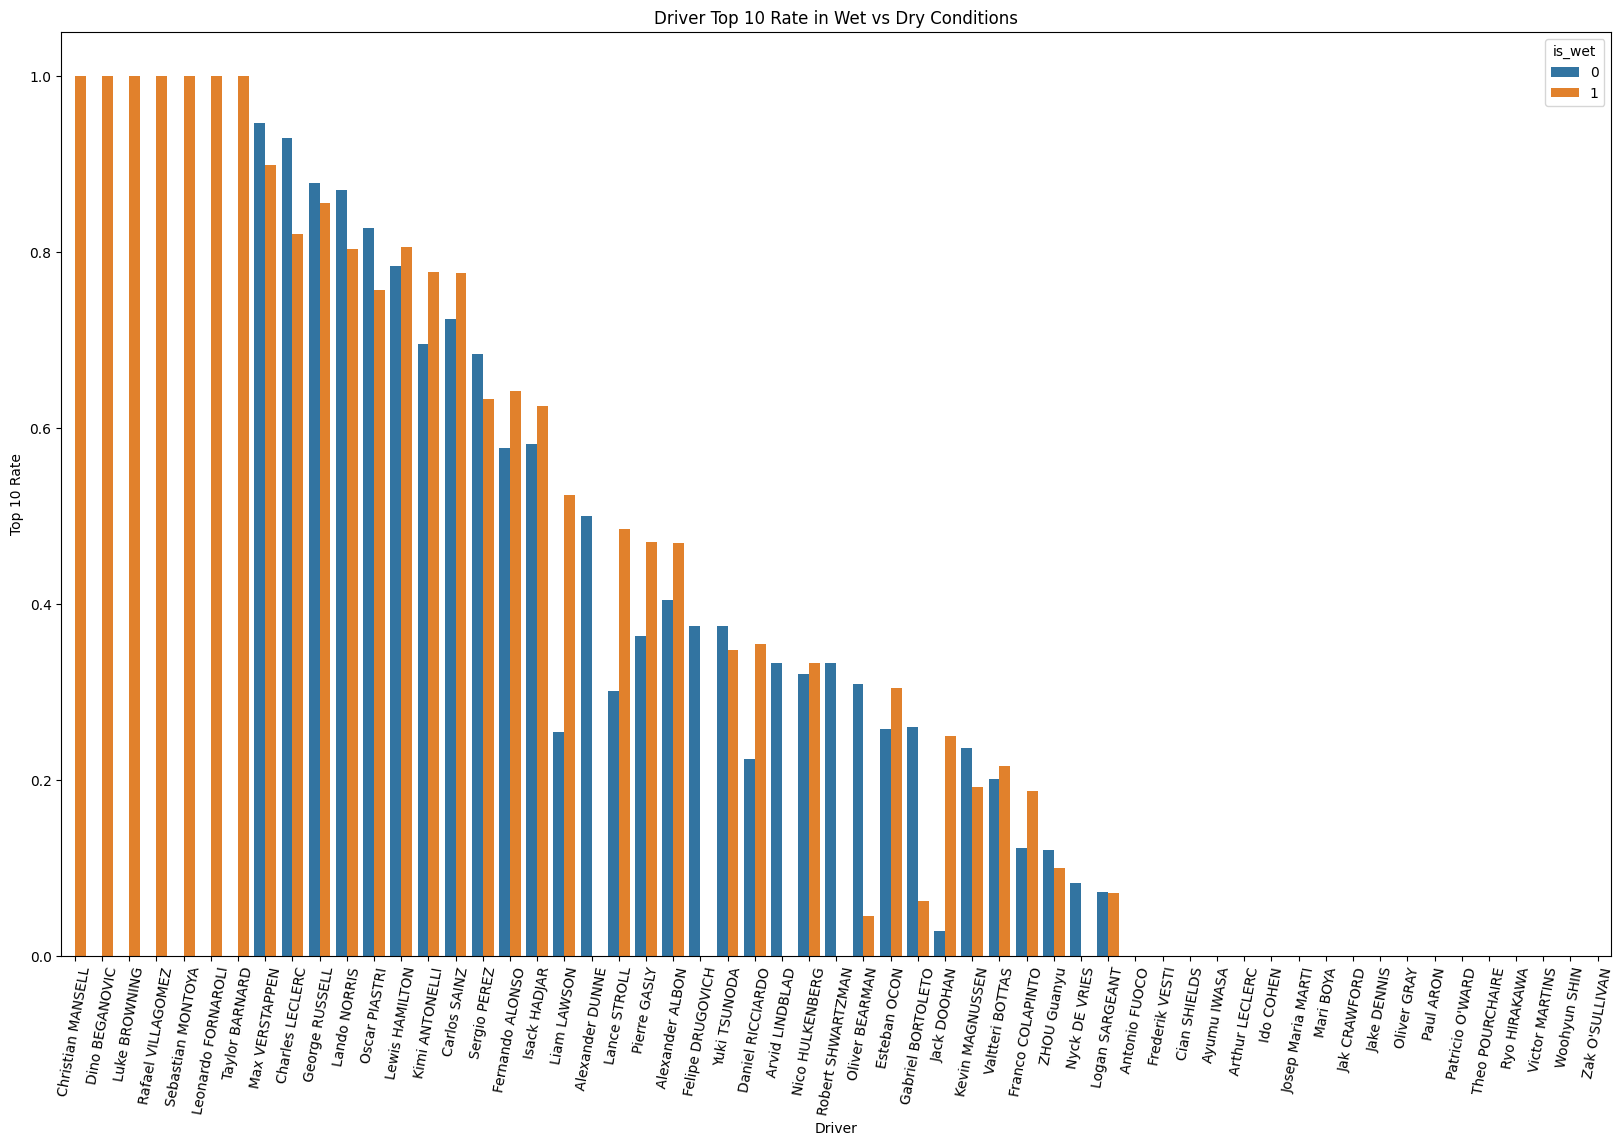

In [16]:
# driver performance in the rain vs non-rain
driver_rain_perf = (
    results.groupby(['full_name','is_wet'])['top_10']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize = (20,12))
sns.barplot(data = driver_rain_perf, x = 'full_name', y = 'top_10', hue = 'is_wet')
plt.title('Driver Top 10 Rate in Wet vs Dry Conditions')
plt.xlabel('Driver')
plt.ylabel('Top 10 Rate')
plt.xticks(rotation=80)
plt.show()

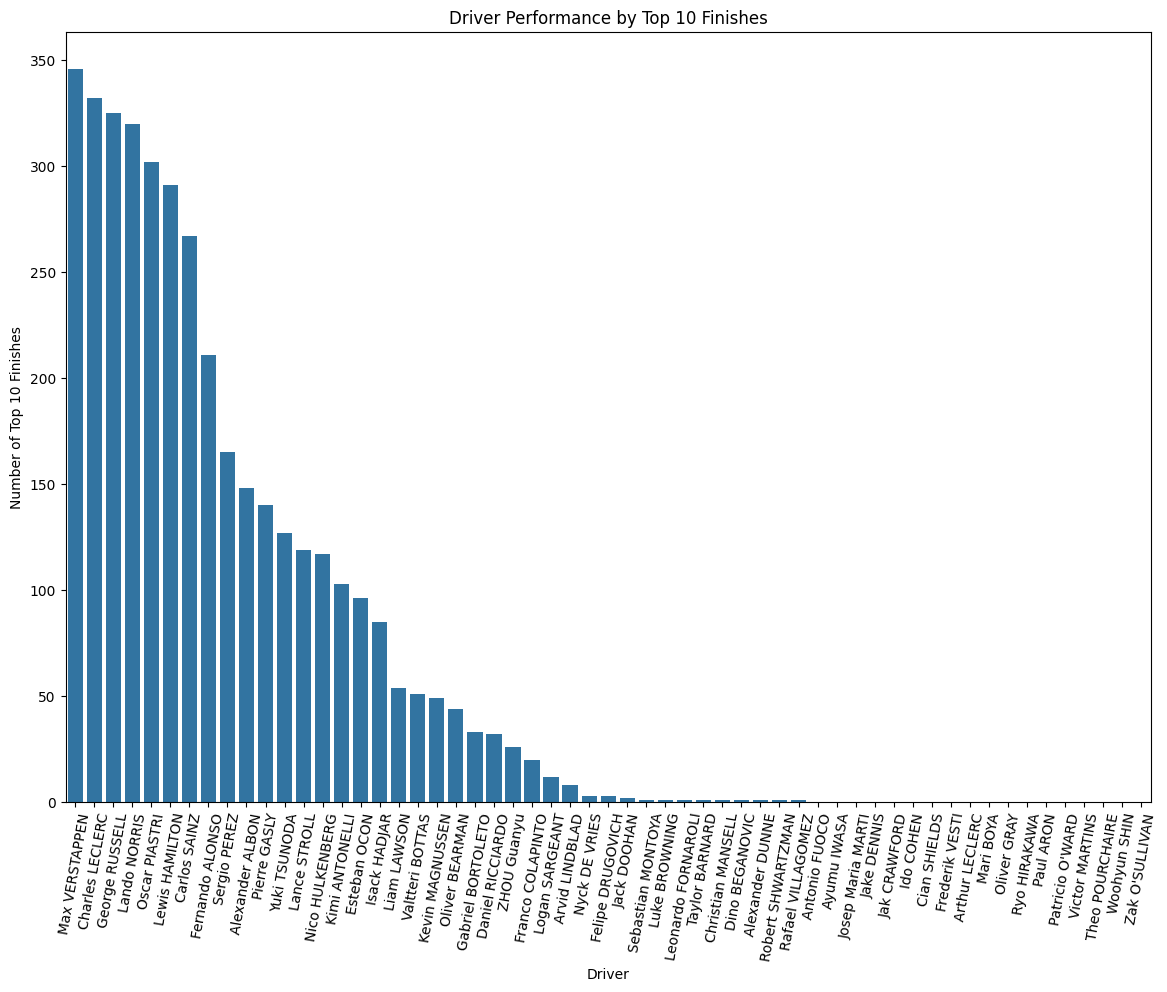

In [25]:
# overall number of top 10 finishes - driver
driver_top10s = (
    results.groupby('full_name')['top_10']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14,10))
sns.barplot(data = driver_top10s, x = 'full_name', y = 'top_10')
plt.xlabel('Driver')
plt.ylabel('Number of Top 10 Finishes')
plt.title('Driver Performance by Top 10 Finishes')
plt.xticks(rotation=80)
plt.show()

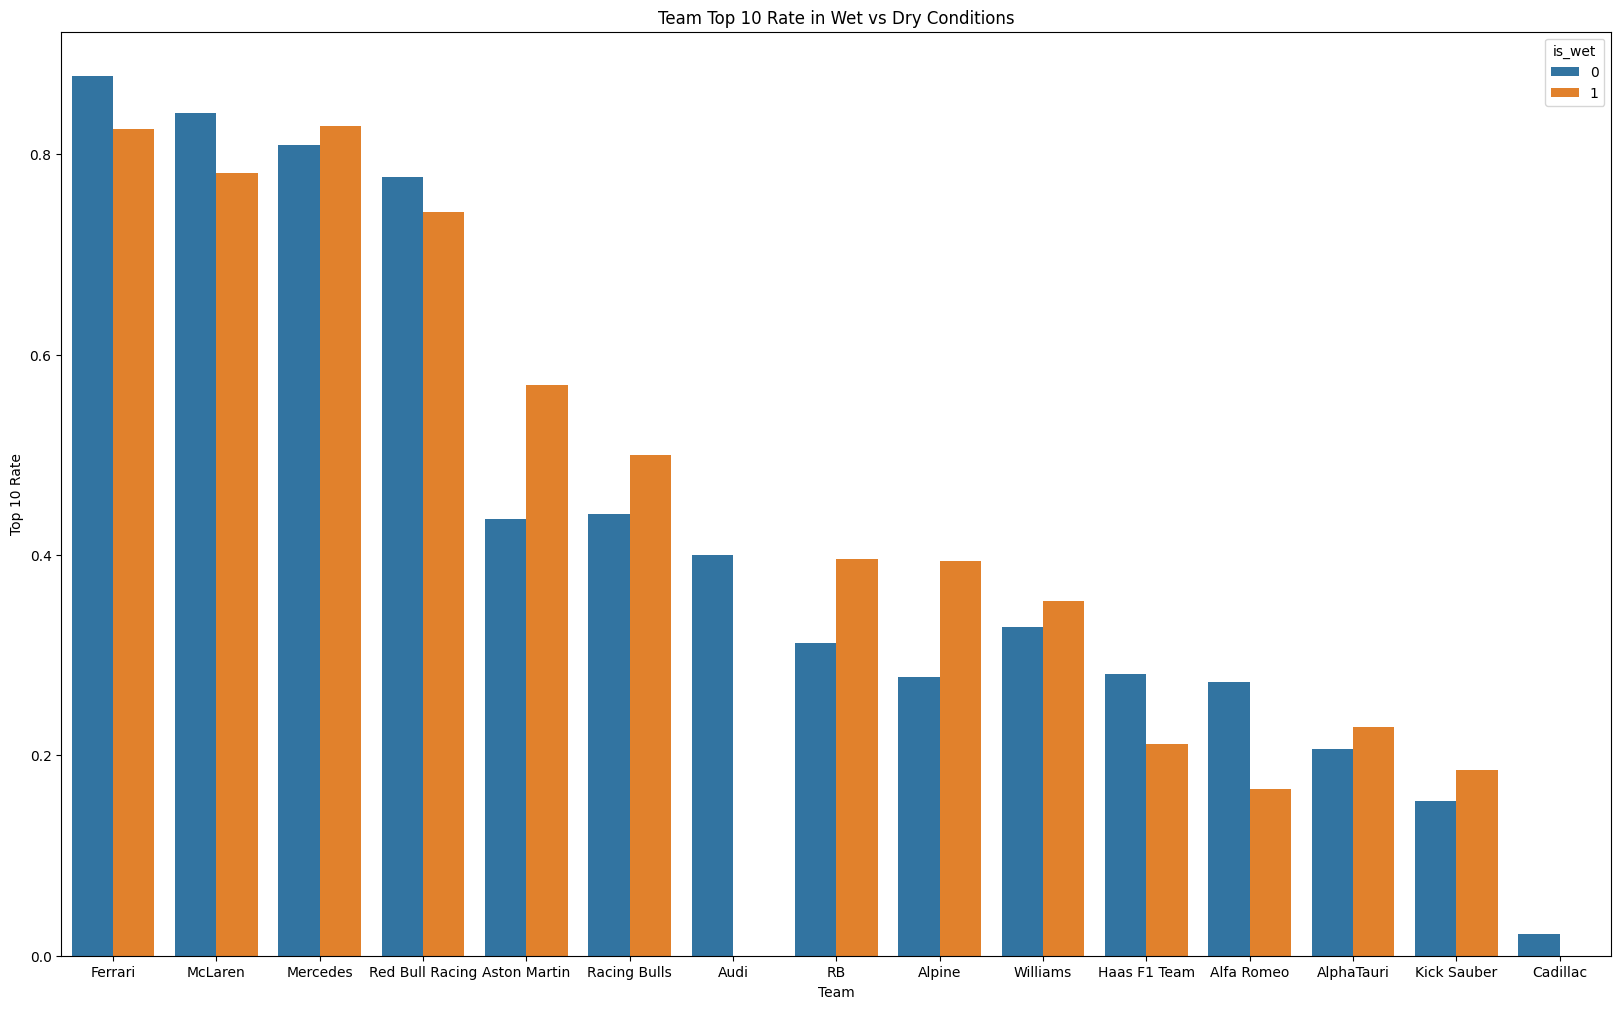

In [17]:
team_rain_perf = (
    results.groupby(['team_name','is_wet'])['top_10']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize = (20,12))
sns.barplot(data = team_rain_perf, x = 'team_name', y = 'top_10', hue = 'is_wet')
plt.title('Team Top 10 Rate in Wet vs Dry Conditions')
plt.xlabel('Team')
plt.ylabel('Top 10 Rate')
plt.show()

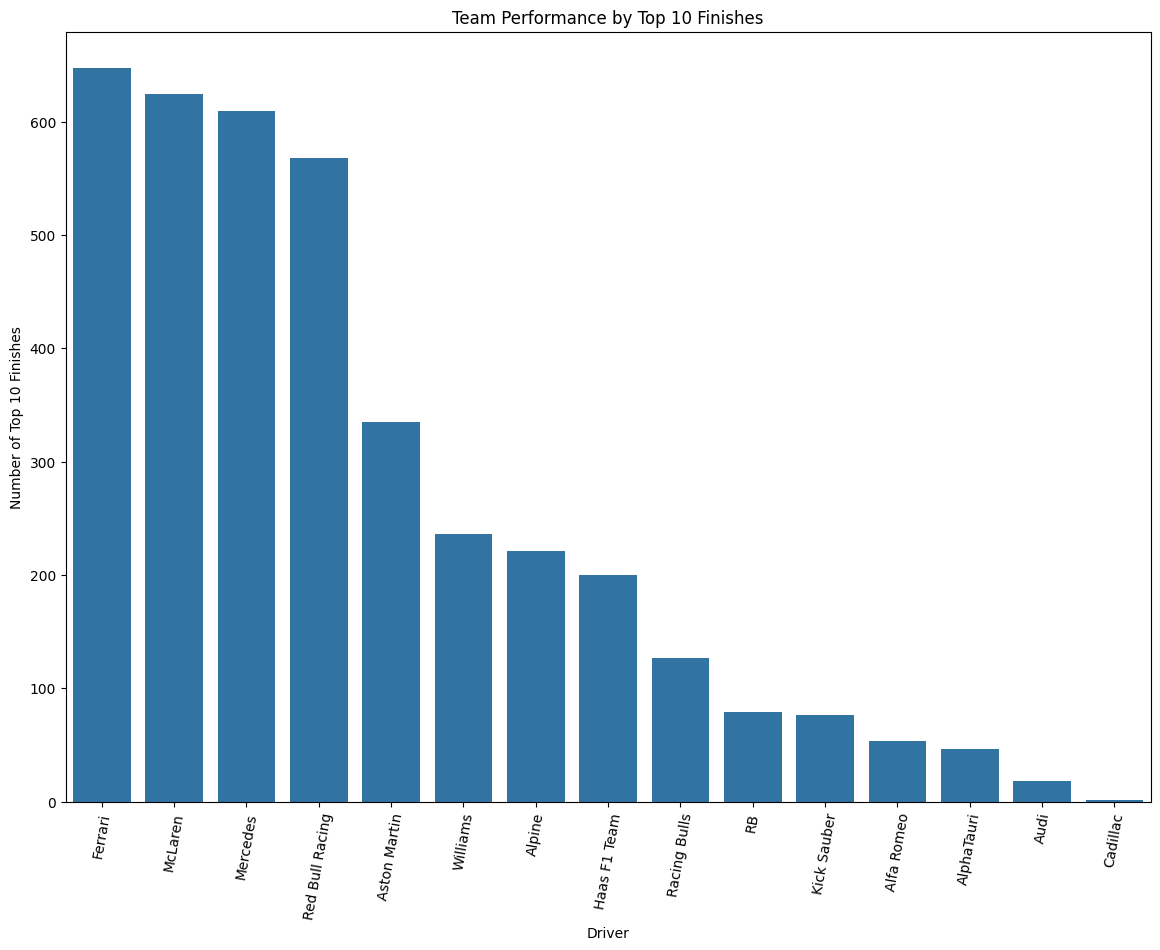

In [26]:
# overall number of top 10 finishes - team
team_top10s = (
    results.groupby('team_name')['top_10']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14,10))
sns.barplot(data = team_top10s, x = 'team_name', y = 'top_10')
plt.xlabel('Driver')
plt.ylabel('Number of Top 10 Finishes')
plt.title('Team Performance by Top 10 Finishes')
plt.xticks(rotation=80)
plt.show()

In [27]:
# tire usage for top 10 finishes

compound_cols = [
    'hard_compound',
    'medium_compound',
    'soft_compound',
    'intermediate_compound',
    'wet_compound'
]

results.groupby('top_10')[compound_cols].mean()

,hard_compound,medium_compound,soft_compound,intermediate_compound,wet_compound
top_10,,,,,
0,0.556733,1.264845,1.692222,0.138835,0.033175
1,0.566667,1.426302,2.260937,0.194792,0.031510


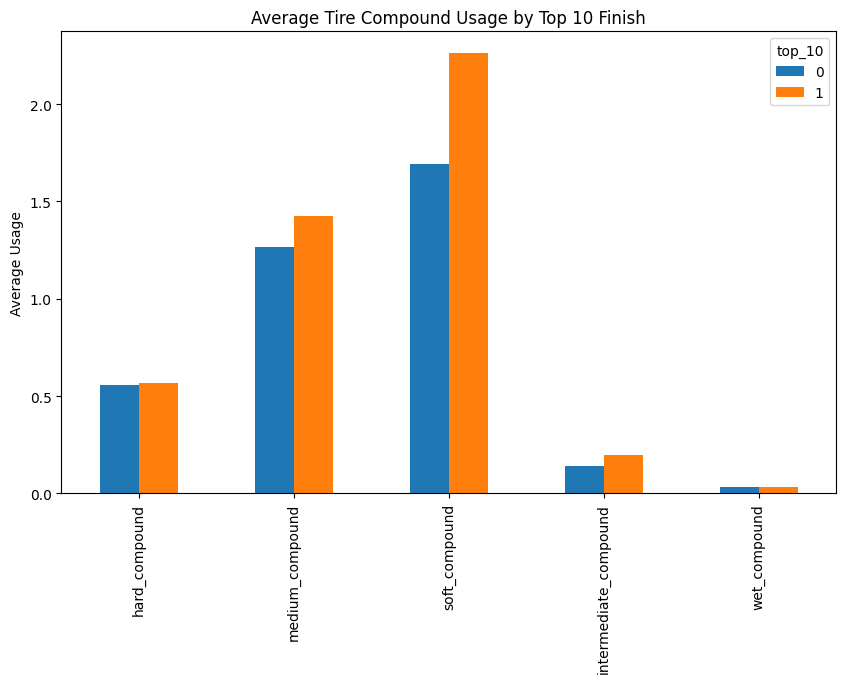

In [28]:
# tire usage for top 10 finishes in the rain vs non-rain

compound_means = (
    results.groupby('top_10')[
        ['hard_compound',
         'medium_compound',
         'soft_compound',
         'intermediate_compound',
         'wet_compound']
    ]
    .mean()
)

compound_means.T.plot(kind='bar', figsize=(10,6))

plt.title('Average Tire Compound Usage by Top 10 Finish')
plt.ylabel('Average Usage')

plt.show()

Modeling

In [43]:
# important predictive features

features = [
    'avg_air_temp',
    'avg_track_temp',
    'avg_humidity',
    'avg_wind_speed',
    'rain_pct',
    'is_wet',
    'team_name',
    'hard_compound',
    'medium_compound',
    'soft_compound',
    'intermediate_compound',
    'wet_compound',
    'total_stints',
    'driver_strength'
]

In [44]:
# split data
train, test = train_test_split(results, random_state = 32)

In [45]:
# create driver strength after split
driver_strength = train.groupby("driver_number")["top_10"].mean()

train["driver_strength"] = train["driver_number"].map(driver_strength)

test["driver_strength"] = test["driver_number"].map(driver_strength)
test["driver_strength"] = test["driver_strength"].fillna(train["top_10"].mean())

In [46]:
# define x and y for train and test sets
X_train = train[features]
X_test = test[features]
y_train = train["top_10"]
y_test = test["top_10"]

In [47]:
# create preprocessor - for categorical and numerical columns
cat_cols = ['team_name']
num_cols = X_train.select_dtypes(include = 'number').columns

preprocessor = make_column_transformer(
    (OneHotEncoder(drop = 'first'), cat_cols),
    (StandardScaler(), num_cols),
    remainder = 'drop'
    )

In [76]:
# instantiate
knn = KNeighborsClassifier()
lgr = LogisticRegression()
rf = RandomForestClassifier()

In [77]:
# create pipelines for each model
knn_pipe = Pipeline([('transform', preprocessor),
                     ('impute', SimpleImputer(strategy='mean')),
                     ('model', knn),
                     ])
lgr_pipe = Pipeline([('transform', preprocessor),
                     ('impute', SimpleImputer(strategy='mean')),
                     ('model', lgr)
                     ])
rf_pipe = Pipeline([('transform', preprocessor),
                    ('impute', SimpleImputer(strategy='mean')),
                    ('model', rf)
                     ])

In [79]:
# fit data
knn_pipe.fit(X_train, y_train)
lgr_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('onehotencoder',
                                                  OneHotEncoder(drop='first'),
                                                  ['team_name']),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  Index(['avg_air_temp', 'avg_track_temp', 'avg_humidity', 'avg_wind_speed',
       'rain_pct', 'is_wet', 'hard_compound', 'medium_compound',
       'soft_compound', 'intermediate_compound', 'wet_compound',
       'total_stints', 'driver_strength'],
      dtype='object'))])),
                ('impute', SimpleImputer()),
                ('model', RandomForestClassifier())])

Text(0.5, 1.0, 'Random Forest Model')

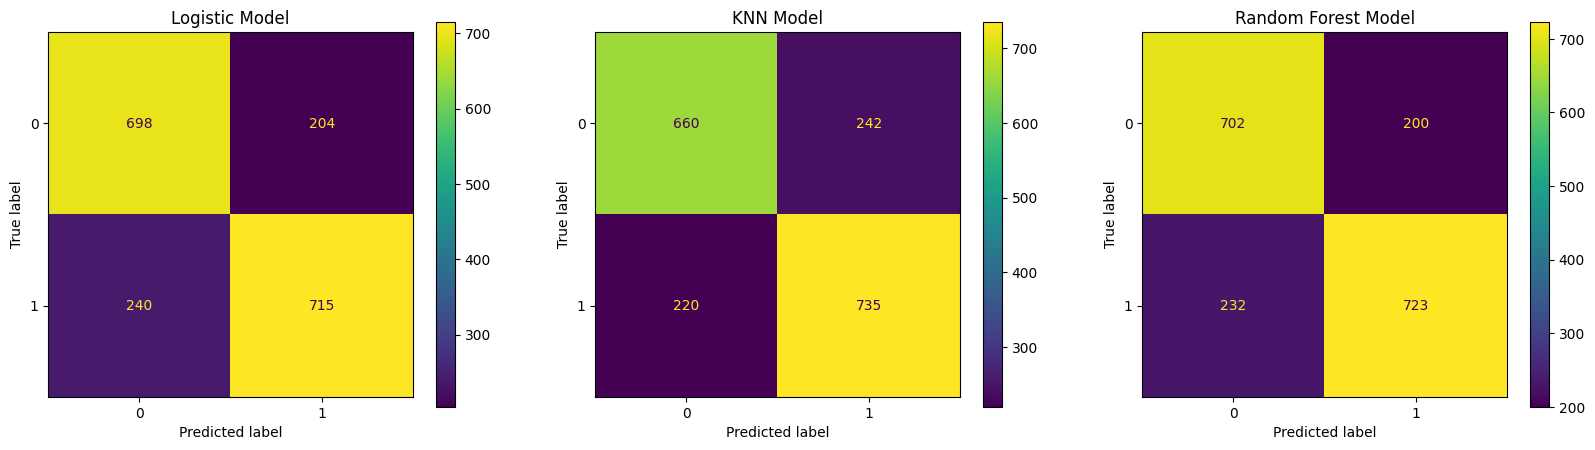

In [84]:
# confusion matrix for each model
fig, ax = plt.subplots(1, 3, figsize = (20, 5))
ConfusionMatrixDisplay.from_estimator(lgr_pipe, X_test, y_test, ax = ax[0])
ax[0].set_title('Logistic Model')

ConfusionMatrixDisplay.from_estimator(knn_pipe, X_test, y_test, ax = ax[1])
ax[1].set_title('KNN Model')

ConfusionMatrixDisplay.from_estimator(rf_pipe, X_test, y_test, ax = ax[2])
ax[2].set_title('Random Forest Model')

In [85]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [104]:
# optimize knn model using a grid search
params_to_search = {'model__n_neighbors': [5, 9, 13, 17, 21, 29, 35, 100]}
knn_grid = GridSearchCV(estimator = knn_pipe, param_grid = params_to_search, scoring = 'f1')

In [105]:
# results of grid search
knn_grid.fit(X_train, y_train)
knn_grid_results = pd.DataFrame(knn_grid.cv_results_)
knn_grid_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.026253,0.005141,0.070895,0.007426,5,{'model__n_neighbors': 5},0.759516,0.750436,0.750427,0.747387,0.758497,0.753253,0.004838,8
1,0.023388,0.000886,0.066828,0.002626,9,{'model__n_neighbors': 9},0.765172,0.752406,0.752166,0.754816,0.768129,0.758538,0.006753,7
2,0.028916,0.009882,0.071255,0.005609,13,{'model__n_neighbors': 13},0.756228,0.746269,0.763066,0.760889,0.770889,0.759468,0.008126,5
3,0.023564,0.001066,0.069461,0.002645,17,{'model__n_neighbors': 17},0.754480,0.746667,0.762905,0.760286,0.768670,0.758602,0.007512,6
4,0.025626,0.001838,0.075908,0.011443,21,{'model__n_neighbors': 21},0.764388,0.744643,0.767340,0.756076,0.771481,0.760786,0.009519,4
5,0.025821,0.004190,0.076140,0.003321,29,{'model__n_neighbors': 29},0.766456,0.740873,0.770723,0.762421,0.763569,0.760808,0.010372,3
6,0.023506,0.000391,0.083551,0.001989,35,{'model__n_neighbors': 35},0.771993,0.746004,0.763251,0.768260,0.765840,0.763069,0.009006,1
7,0.022059,0.000771,0.117189,0.005071,100,{'model__n_neighbors': 100},0.769510,0.745520,0.772930,0.770626,0.756256,0.762968,0.010490,2


In [106]:
best_knn_model = knn_grid.best_estimator_

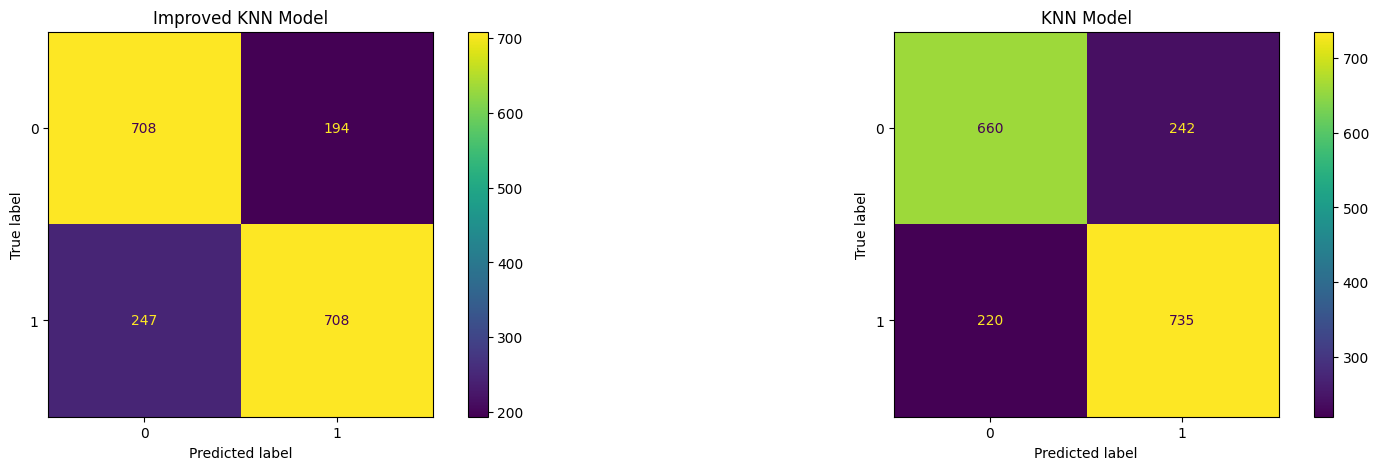

In [107]:
# confusion matrices comparing before and after optimization
fig, ax = plt.subplots(1, 2, figsize = (20, 5))
ConfusionMatrixDisplay.from_estimator(best_knn_model, X_test, y_test, ax = ax[0])
ax[0].set_title('Improved KNN Model')
ConfusionMatrixDisplay.from_estimator(knn_pipe, X_test, y_test, ax = ax[1])
ax[1].set_title('KNN Model');

In [108]:
# optimize random forest model using a grid search
rf_params = {'model__n_estimators': [100, 200], 'model__max_depth': [5, 10, 15, None], 'model__min_samples_split': [2, 5, 10]}
rf_grid = GridSearchCV(rf_pipe, rf_params, cv=5, scoring='f1')

In [109]:
# results of grid search
rf_grid.fit(X_train, y_train)
rf_grid_results = pd.DataFrame(rf_grid.cv_results_)
rf_grid_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__min_samples_split,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.594254,0.026705,0.032879,0.005156,5,2,100,"{'model__max_depth': 5, 'model__min_samples_sp...",0.765880,0.750000,0.773905,0.789238,0.780797,0.771964,0.013413,20
1,1.341822,0.425450,0.060168,0.024715,5,2,200,"{'model__max_depth': 5, 'model__min_samples_sp...",0.769231,0.750221,0.776786,0.790279,0.779692,0.773242,0.013345,17
2,0.396216,0.064899,0.019766,0.000730,5,5,100,"{'model__max_depth': 5, 'model__min_samples_sp...",0.771041,0.751773,0.781445,0.787770,0.778487,0.774103,0.012393,15
3,0.721307,0.015246,0.030119,0.000813,5,5,200,"{'model__max_depth': 5, 'model__min_samples_sp...",0.774597,0.750442,0.779174,0.791778,0.777676,0.774734,0.013483,13
4,0.414034,0.088631,0.024547,0.006944,5,10,100,"{'model__max_depth': 5, 'model__min_samples_sp...",0.759890,0.751107,0.780749,0.783636,0.767072,0.768491,0.012311,24
5,0.874433,0.179189,0.036172,0.009365,5,10,200,"{'model__max_depth': 5, 'model__min_samples_sp...",0.756906,0.750000,0.782063,0.787770,0.778281,0.771004,0.014807,23
6,0.584572,0.015092,0.027357,0.003542,10,2,100,"{'model__max_depth': 10, 'model__min_samples_s...",0.767808,0.760286,0.783078,0.790146,0.764319,0.773127,0.011484,18
7,1.271315,0.215867,0.050683,0.010521,10,2,200,"{'model__max_depth': 10, 'model__min_samples_s...",0.770370,0.765653,0.783542,0.786558,0.766355,0.774496,0.008818,14
8,0.616675,0.107144,0.028253,0.005121,10,5,100,"{'model__max_depth': 10, 'model__min_samples_s...",0.765683,0.757194,0.778175,0.786885,0.768943,0.771376,0.010259,21
9,1.129780,0.012137,0.042147,0.003045,10,5,200,"{'model__max_depth': 10, 'model__min_samples_s...",0.757914,0.759857,0.781671,0.787215,0.770093,0.771350,0.011597,22


In [103]:
best_rf_model = rf_grid.best_estimator_

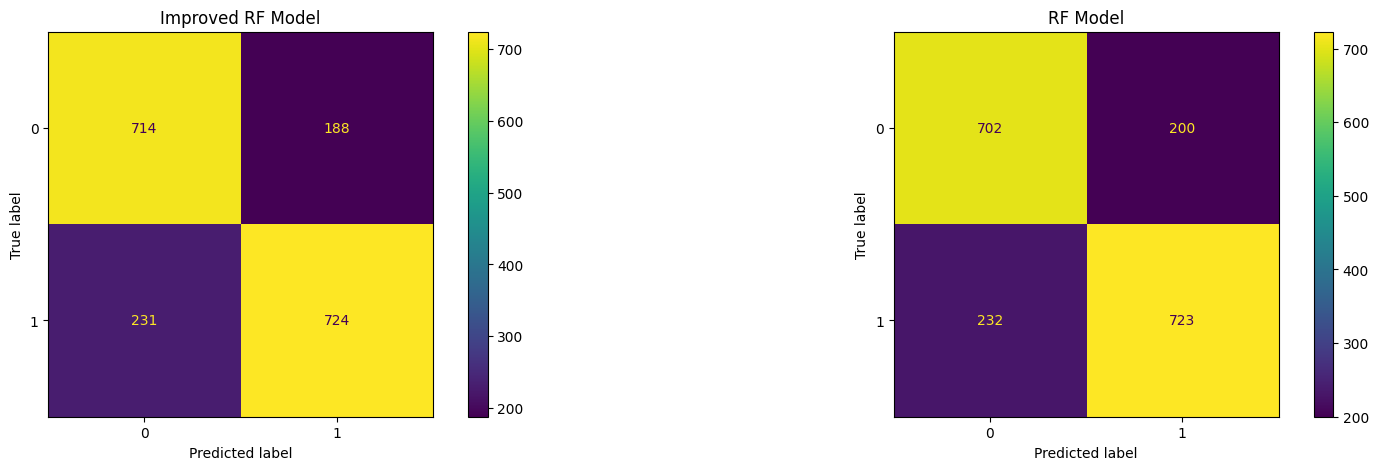

In [113]:
# confusion matrices comparing before and after optimization
fig, ax = plt.subplots(1, 2, figsize = (20, 5))
ConfusionMatrixDisplay.from_estimator(best_rf_model, X_test, y_test, ax = ax[0])
ax[0].set_title('Improved RF Model')
ConfusionMatrixDisplay.from_estimator(rf_pipe, X_test, y_test, ax = ax[1])
ax[1].set_title('RF Model');

In [112]:
# view of classification report for all three models
print("Tuned KNN")
print(classification_report(y_test, best_knn_model.predict(X_test)))
print("Logistic Regression")
print(classification_report(y_test, lgr_pipe.predict(X_test)))
print("Random Forest")
print(classification_report(y_test, best_rf_model.predict(X_test)))

Tuned KNN
              precision    recall  f1-score   support

           0       0.74      0.78      0.76       902
           1       0.78      0.74      0.76       955

    accuracy                           0.76      1857
   macro avg       0.76      0.76      0.76      1857
weighted avg       0.76      0.76      0.76      1857

Logistic Regression
              precision    recall  f1-score   support

           0       0.74      0.77      0.76       902
           1       0.78      0.75      0.76       955

    accuracy                           0.76      1857
   macro avg       0.76      0.76      0.76      1857
weighted avg       0.76      0.76      0.76      1857

Random Forest
              precision    recall  f1-score   support

           0       0.76      0.79      0.77       902
           1       0.79      0.76      0.78       955

    accuracy                           0.77      1857
   macro avg       0.77      0.77      0.77      1857
weighted avg       0.78      0